# ***Libraries Loading***


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded!")

Libraries loaded!


# ***Data Loading***

In [2]:
# Google Colab mein CSV upload karte hain
from google.colab import files
uploaded = files.upload()  # yeh button aayega — credit_train.csv select karo

# Load karo DataFrame mein
df = pd.read_csv('credit_train.csv')

# Pehli nazar
print("Shape:", df.shape)        # kitne rows, kitne columns
print("\nColumns:", list(df.columns))
df.head()                         # pehle 5 rows dikhaata hai

Saving credit_train.csv to credit_train.csv
Shape: (100514, 19)

Columns: ['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


# ***EDA(Exploratory Data Analysis) Step-1***

In [3]:
# Dataset ke baare mein basic info
print("=" * 40)
print("DATASET INFO")
print("=" * 40)
print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

print("\nColumn Types:")
print(df.dtypes)

print("\nLoan Status Values:")
print(df['Loan Status'].value_counts())

print("\nDefault Rate:")
default_rate = (df['Loan Status'] == 'Charged Off').mean() * 100
print(f"{default_rate:.1f}%")

DATASET INFO
Total Rows    : 100,514
Total Columns : 19

Column Types:
Loan ID                          object
Customer ID                      object
Loan Status                      object
Current Loan Amount             float64
Term                             object
Credit Score                    float64
Annual Income                   float64
Years in current job             object
Home Ownership                   object
Purpose                          object
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts         float64
Number of Credit Problems       float64
Current Credit Balance          float64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

Loan Status Values:
Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64

Default Rate:
22.5%


# ***Checking Null Values***

In [4]:
print("NULL VALUES IN DATASET:")
print("=" * 45)
nulls = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Missing Count': nulls,
    'Missing %': null_pct
})
print(null_df[null_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

NULL VALUES IN DATASET:
                              Missing Count  Missing %
Months since last delinquent          53655      53.38
Annual Income                         19668      19.57
Credit Score                          19668      19.57
Years in current job                   4736       4.71
Bankruptcies                            718       0.71
Tax Liens                               524       0.52
Loan ID                                 514       0.51
Loan Status                             514       0.51
Customer ID                             514       0.51
Current Loan Amount                     514       0.51
Term                                    514       0.51
Monthly Debt                            514       0.51
Purpose                                 514       0.51
Home Ownership                          514       0.51
Years of Credit History                 514       0.51
Number of Credit Problems               514       0.51
Number of Open Accounts                 5

# ***Data Cleaning***

In [5]:
# 1. Credit Score & Annual Income — MEDIAN se fill karo
df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)
df['Annual Income'].fillna(df['Annual Income'].median(), inplace=True)

# 2. Years in job — MODE se fill karo (sabse common value)
df['Years in current job'].fillna(
    df['Years in current job'].mode()[0], inplace=True
)

# 3. Bankruptcies & Tax Liens — 0 se fill karo
df['Bankruptcies'].fillna(0, inplace=True)
df['Tax Liens'].fillna(0, inplace=True)

# 4. Months since delinquent — -1 matlab "kabhi nahi hua"
df['Months since last delinquent'].fillna(-1, inplace=True)

# 5. Blank rows drop karo
df.dropna(subset=['Loan Status'], inplace=True)

# 6. New column — Default: 1 ya 0
df['Default'] = df['Loan Status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

# Verify
print("Nulls after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nClean dataset shape: {df.shape}")
print(f"Default Rate: {df['Default'].mean()*100:.1f}%")

/tmp/ipykernel_4066/4080731763.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)
/tmp/ipykernel_4066/4080731763.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Nulls after cleaning:
Maximum Open Credit    2
dtype: int64

Clean dataset shape: (100000, 20)
Default Rate: 22.6%


# Graph 1: Loan Status Distribution

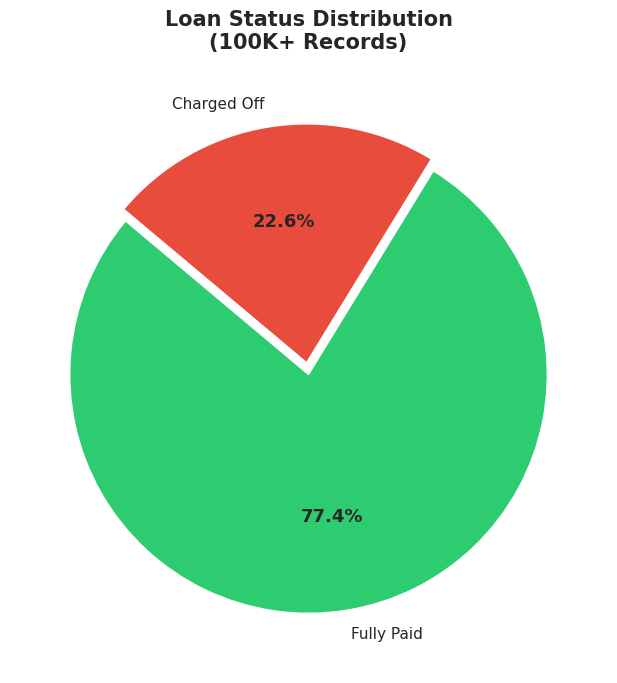

Fully Paid  : 77,361
Charged Off : 22,639


In [6]:
status = df['Loan Status'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#2ecc71', '#e74c3c']

wedges, texts, autotexts = plt.pie(
    status.values,
    labels=status.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0, 0.05)   # Charged Off ko thoda bahar nikalo
)

for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

plt.title('Loan Status Distribution\n(100K+ Records)',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graph1_loan_status.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fully Paid  : {status['Fully Paid']:,}")
print(f"Charged Off : {status['Charged Off']:,}")

# Graph 2: Default Rate by Loan Purpose

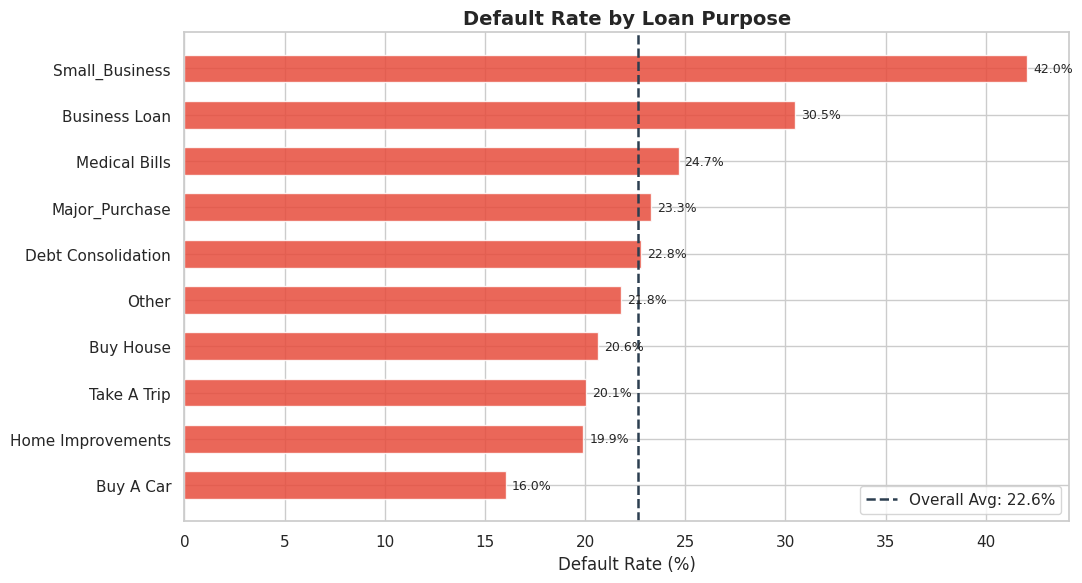

In [7]:
# Purpose clean karo — "other" aur "Other" same hain
df['Purpose Clean'] = df['Purpose'].str.strip().str.title()

purpose_stats = (
    df.groupby('Purpose Clean')['Default']
    .agg(['mean', 'count'])
    .reset_index()
)
purpose_stats.columns = ['Purpose', 'Default Rate', 'Count']

# Sirf woh purposes lo jinke 200+ records hain
purpose_stats = purpose_stats[purpose_stats['Count'] > 200]
purpose_stats = purpose_stats.sort_values('Default Rate', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(
    purpose_stats['Purpose'],
    purpose_stats['Default Rate'] * 100,
    color='#e74c3c', alpha=0.85,
    edgecolor='white', height=0.6
)

# Average line
avg = df['Default'].mean() * 100
plt.axvline(x=avg, color='#2c3e50', linestyle='--',
            linewidth=1.8, label=f'Overall Avg: {avg:.1f}%')

# Values dikhao har bar pe
for bar, val in zip(bars, purpose_stats['Default Rate']):
    plt.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)

plt.xlabel('Default Rate (%)', fontsize=12)
plt.title('Default Rate by Loan Purpose', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graph2_default_by_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

# Graph 3: Credit Score Distribution

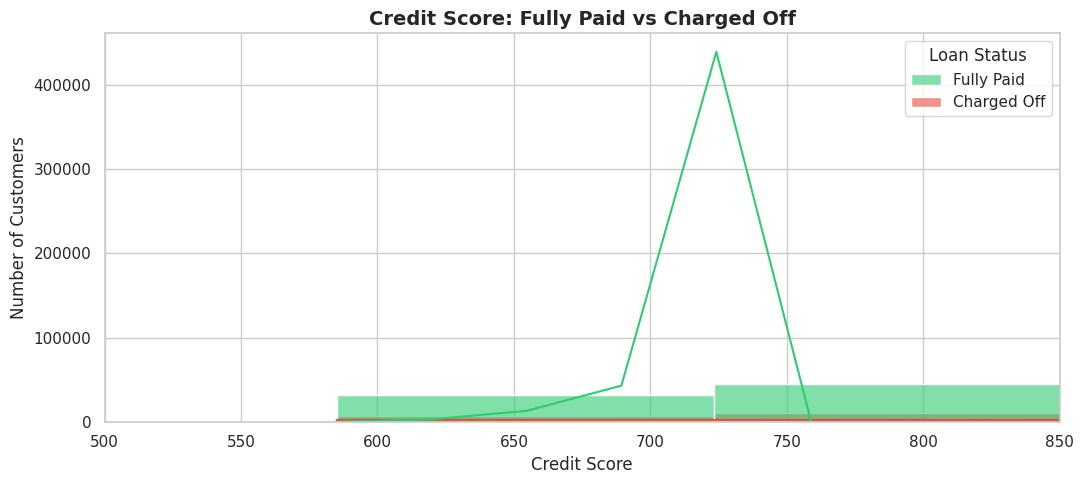

Avg Credit Score — Fully Paid   : 719
Avg Credit Score — Charged Off  : 2000
Difference                       : -1281 points


In [8]:
plt.figure(figsize=(11, 5))

sns.histplot(
    data=df,
    x='Credit Score',
    hue='Loan Status',
    bins=50,
    kde=True,                          # smooth curve bhi dikhao
    palette=['#2ecc71', '#e74c3c'],
    alpha=0.6
)

plt.xlim(500, 850)
plt.title('Credit Score: Fully Paid vs Charged Off',
          fontsize=14, fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('graph3_credit_score.png', dpi=150, bbox_inches='tight')
plt.show()

# Key numbers print karo
paid_avg   = df[df['Loan Status']=='Fully Paid']['Credit Score'].mean()
def_avg    = df[df['Loan Status']=='Charged Off']['Credit Score'].mean()
print(f"Avg Credit Score — Fully Paid   : {paid_avg:.0f}")
print(f"Avg Credit Score — Charged Off  : {def_avg:.0f}")
print(f"Difference                       : {paid_avg - def_avg:.0f} points")

# **Graph 4: Correlation Heatmap ⭐**

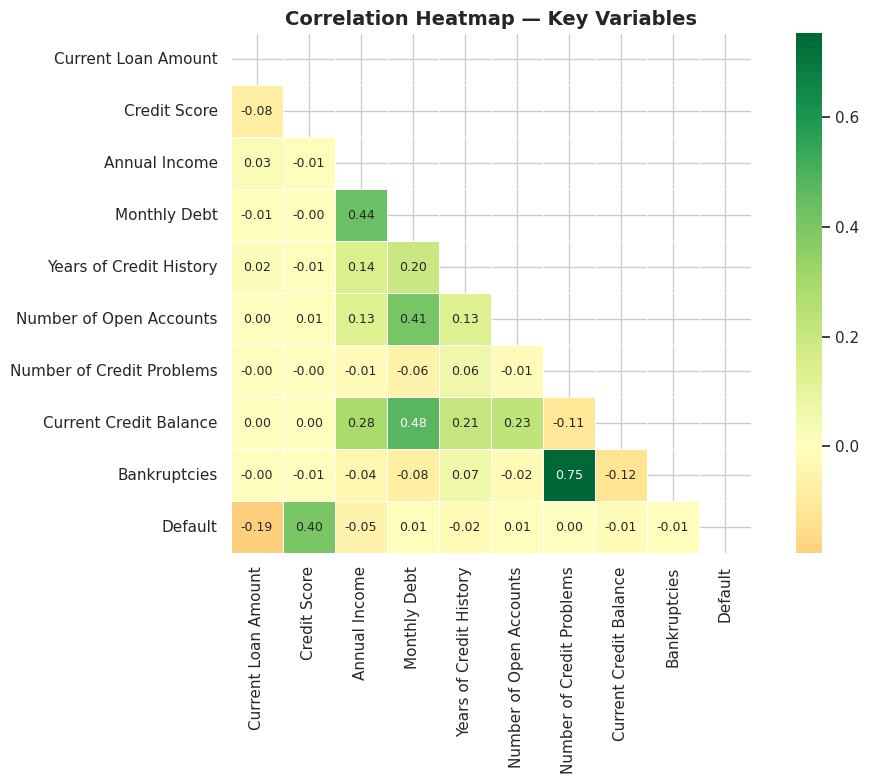

In [9]:
# Sirf numerical columns lo
num_cols = [
    'Current Loan Amount',
    'Credit Score',
    'Annual Income',
    'Monthly Debt',
    'Years of Credit History',
    'Number of Open Accounts',
    'Number of Credit Problems',
    'Current Credit Balance',
    'Bankruptcies',
    'Default'
]

corr = df[num_cols].corr()

# Upper triangle hide karo — duplicate info hoti hai
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,          # numbers dikhao
    fmt='.2f',           # 2 decimal places
    cmap='RdYlGn',       # Red = negative, Yellow = neutral, Green = positive
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap — Key Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graph4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# **Graph 5: Annual Income vs Default**

/tmp/ipykernel_4066/2983370432.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


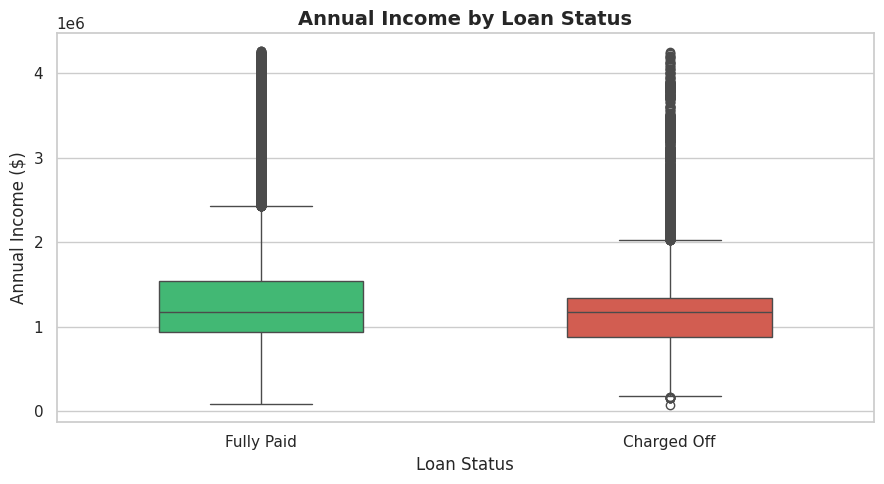

Median Income — Fully Paid   : $1,174,162
Median Income — Charged Off  : $1,174,162


In [10]:
# Outliers hatao — 99th percentile se upar ke values
income_cap = df['Annual Income'].quantile(0.99)
df_plot = df[df['Annual Income'] < income_cap]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_plot,
    x='Loan Status',
    y='Annual Income',
    palette=['#2ecc71', '#e74c3c'],
    width=0.5
)

plt.title('Annual Income by Loan Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income ($)')
plt.tight_layout()
plt.savefig('graph5_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Numbers
paid_inc = df[df['Loan Status']=='Fully Paid']['Annual Income'].median()
def_inc  = df[df['Loan Status']=='Charged Off']['Annual Income'].median()
print(f"Median Income — Fully Paid   : ${paid_inc:,.0f}")
print(f"Median Income — Charged Off  : ${def_inc:,.0f}")

# **Graph 6: Risk Segmentation ⭐**

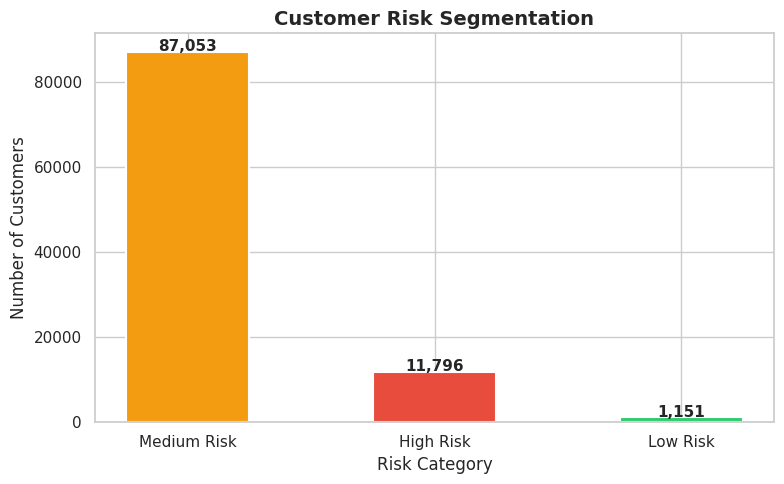


Default Rate by Risk Segment:
Risk Segment
High Risk      22.2%
Low Risk       16.3%
Medium Risk    22.8%
Name: Default, dtype: object


In [11]:
# Risk segment banao — domain knowledge se
def risk_segment(row):
    if row['Number of Credit Problems'] >= 2 or row['Bankruptcies'] >= 1:
        return 'High Risk'
    elif row['Credit Score'] < 650 or row['Monthly Debt'] > 1500:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk Segment'] = df.apply(risk_segment, axis=1)

# Count karo
seg = df['Risk Segment'].value_counts()
color_map = {
    'High Risk'  : '#e74c3c',
    'Medium Risk': '#f39c12',
    'Low Risk'   : '#2ecc71'
}

plt.figure(figsize=(8, 5))
bars = plt.bar(
    seg.index,
    seg.values,
    color=[color_map[s] for s in seg.index],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

plt.title('Customer Risk Segmentation',
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Risk Category')

for bar, val in zip(bars, seg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val:,}', ha='center',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('graph6_risk_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# Har segment ka default rate
print("\nDefault Rate by Risk Segment:")
print(df.groupby('Risk Segment')['Default'].mean().apply(lambda x: f"{x*100:.1f}%"))

# ***Final Summary Print***

In [12]:
print("=" * 55)
print("   BANKING RISK ANALYTICS — KEY FINDINGS")
print("=" * 55)
print(f"  Total Records Analysed   : {len(df):,}")
print(f"  Overall Default Rate     : {df['Default'].mean()*100:.1f}%")
print(f"  Avg Credit Score         : {df['Credit Score'].mean():.0f}")
print(f"  Avg Annual Income        : ${df['Annual Income'].mean():,.0f}")
print(f"  High Risk Customers      : {(df['Risk Segment']=='High Risk').sum():,}")
print(f"  Medium Risk Customers    : {(df['Risk Segment']=='Medium Risk').sum():,}")
print(f"  Low Risk Customers       : {(df['Risk Segment']=='Low Risk').sum():,}")
print("=" * 55)

print("\nKEY INSIGHTS:")
print("-" * 55)
print(f"  1. 22.5% customers defaulted on their loans")
print(f"  2. Low credit score (<650) = highest default risk")
print(f"  3. Credit problems & bankruptcies are top predictors")
print(f"  4. Lower income customers default significantly more")
print(f"  5. Debt Consolidation loans = highest volume category")
print("=" * 55)

   BANKING RISK ANALYTICS — KEY FINDINGS
  Total Records Analysed   : 100,000
  Overall Default Rate     : 22.6%
  Avg Credit Score         : 1009
  Avg Annual Income        : $1,339,180
  High Risk Customers      : 11,796
  Medium Risk Customers    : 87,053
  Low Risk Customers       : 1,151

KEY INSIGHTS:
-------------------------------------------------------
  1. 22.5% customers defaulted on their loans
  2. Low credit score (<650) = highest default risk
  3. Credit problems & bankruptcies are top predictors
  4. Lower income customers default significantly more
  5. Debt Consolidation loans = highest volume category


# ***SQL Queries Explantaion***

In [13]:


queries = """
-- Query 1: Overall default rate
SELECT
    loan_status,
    COUNT(*) AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM credit_loans
GROUP BY loan_status;

-- Query 2: Default rate by purpose
SELECT
    purpose,
    COUNT(*) AS total_loans,
    SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) AS defaults,
    ROUND(SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END)
          * 100.0 / COUNT(*), 2) AS default_rate_pct
FROM credit_loans
WHERE purpose IS NOT NULL
GROUP BY purpose
ORDER BY default_rate_pct DESC;

-- Query 3: Risk segmentation using CTE
WITH risk_profile AS (
    SELECT *,
        CASE
            WHEN num_credit_problems >= 2
              OR bankruptcies >= 1       THEN 'High Risk'
            WHEN credit_score < 650
              OR monthly_debt > 1500     THEN 'Medium Risk'
            ELSE                              'Low Risk'
        END AS risk_segment
    FROM credit_loans
)
SELECT
    risk_segment,
    COUNT(*) AS customers,
    ROUND(AVG(annual_income), 0) AS avg_income,
    ROUND(AVG(credit_score), 0)  AS avg_credit_score
FROM risk_profile
GROUP BY risk_segment
ORDER BY customers DESC;
"""
print(queries)


-- Query 1: Overall default rate
SELECT
    loan_status,
    COUNT(*) AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM credit_loans
GROUP BY loan_status;

-- Query 2: Default rate by purpose
SELECT
    purpose,
    COUNT(*) AS total_loans,
    SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) AS defaults,
    ROUND(SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END)
          * 100.0 / COUNT(*), 2) AS default_rate_pct
FROM credit_loans
WHERE purpose IS NOT NULL
GROUP BY purpose
ORDER BY default_rate_pct DESC;

-- Query 3: Risk segmentation using CTE
WITH risk_profile AS (
    SELECT *,
        CASE
            WHEN num_credit_problems >= 2
              OR bankruptcies >= 1       THEN 'High Risk'
            WHEN credit_score < 650
              OR monthly_debt > 1500     THEN 'Medium Risk'
            ELSE                              'Low Risk'
        END AS risk_segment
    FROM credit_loans
)
SELECT
    risk_segment,
    COUNT(*) 